#📌 Extracción

In [11]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# Conexión a la API
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
response.raise_for_status()
data = response.json()

# Conversión a DataFrame
df = pd.json_normalize(data)

print(f"Datos cargados correctamente")
print(f"Shape: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())

Datos cargados correctamente
Shape: 7267 filas x 21 columnas


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [12]:
# ── Exploración de columnas y tipos de dato

# 1. Información general del DataFrame
print("INFORMACIÓN GENERAL DEL DATASET:")
print("="*50)
df.info()

# 2. Tipos de dato por columna
print("\n\n TIPOS DE DATO POR COLUMNA:")
print("="*50)
print(df.dtypes)

# 3. Primeras filas para visualizar el contenido
print("\n\n MUESTRA DE LOS DATOS:")
print("="*50)
display(df.head())

# 4. Nombres de todas las columnas disponibles
print("\n\n COLUMNAS DISPONIBLES EN EL DATASET:")
print("="*50)
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col}")

INFORMACIÓN GENERAL DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSu

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4




 COLUMNAS DISPONIBLES EN EL DATASET:
  01. customerID
  02. Churn
  03. customer.gender
  04. customer.SeniorCitizen
  05. customer.Partner
  06. customer.Dependents
  07. customer.tenure
  08. phone.PhoneService
  09. phone.MultipleLines
  10. internet.InternetService
  11. internet.OnlineSecurity
  12. internet.OnlineBackup
  13. internet.DeviceProtection
  14. internet.TechSupport
  15. internet.StreamingTV
  16. internet.StreamingMovies
  17. account.Contract
  18. account.PaperlessBilling
  19. account.PaymentMethod
  20. account.Charges.Monthly
  21. account.Charges.Total


In [20]:
# Comprobación de incoherencias en los datos

# 1. Valores ausentes
print(" VALORES AUSENTES POR COLUMNA:")
print("="*50)
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
display(nulos_df[nulos_df['Nulos'] > 0])

# 2. Filas duplicadas
print("\n\n FILAS DUPLICADAS:")
print("="*50)
print(f"  Total de filas duplicadas: {df.duplicated().sum()}")

# 3. Valores únicos en columnas categóricas (detectar inconsistencias)
print("\n\n VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS:")
print("="*50)
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    unicos = df[col].unique()
    print(f"\n  {col} ({len(unicos)} únicos):")
    print(f"     {unicos}")

# 4. Verificar columnas numéricas con valores sospechosos
print("\n\n ESTADÍSTICAS DE COLUMNAS NUMÉRICAS:")
print("="*50)
display(df.describe())

 VALORES AUSENTES POR COLUMNA:


,Nulos,% del total
Cargos_Totales,11,0.16




 FILAS DUPLICADAS:
  Total de filas duplicadas: 0


 VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS:

  ID_Cliente (7043 únicos):
     ['0002-orfbo' '0003-mknfe' '0004-tlhlj' ... '9992-ujoel' '9993-lhieb'
 '9995-hotoh']

  Genero (2 únicos):
     ['Femenino' 'Masculino']

  Lineas_Multiples (3 únicos):
     ['no' 'yes' 'no phone service']

  Servicio_Internet (3 únicos):
     ['DSL' 'Fibra óptica' 'Sin internet']

  Seguridad_Online (3 únicos):
     ['no' 'yes' 'no internet service']

  Respaldo_Online (3 únicos):
     ['yes' 'no' 'no internet service']

  Proteccion_Dispositivo (3 únicos):
     ['no' 'yes' 'no internet service']

  Soporte_Tecnico (3 únicos):
     ['yes' 'no' 'no internet service']

  Streaming_TV (3 únicos):
     ['yes' 'no' 'no internet service']

  Streaming_Peliculas (3 únicos):
     ['no' 'yes' 'no internet service']

  Tipo_Contrato (3 únicos):
     ['Un año' 'Mes a mes' 'Dos años']

  Metodo_Pago (4 únicos):
     ['Cheque por correo' 'Cheque electrónico' 'Tarjeta de 

,Evasion,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Factura_Digital,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.300441,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.771362,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.450000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.737500,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [14]:
# Manejo de inconsistencias

# 1. Corregir columna Churn: reemplazar '' por NaN y eliminar esas filas
print(" ANTES - Valores únicos en Churn:")
print(f"  {df['Churn'].unique()}")
print(f"  Total filas: {len(df)}")

df['Churn'] = df['Churn'].str.strip()              # eliminar espacios en blanco
df['Churn'] = df['Churn'].replace('', pd.NA)       # reemplazar '' por NaN real
df = df.dropna(subset=['Churn'])                   # eliminar filas sin valor en Churn

print("\n DESPUÉS - Valores únicos en Churn:")
print(f"  {df['Churn'].unique()}")
print(f"  Total filas tras limpieza: {len(df)}")

# 2. Convertir account.Charges.Total de string a float
print("\n\n Antes - Tipo de dato en account.Charges.Total:")
print(f"  {df['account.Charges.Total'].dtype}")

df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

print("\n Despues - Tipo de dato en account.Charges.Total:")
print(f"  {df['account.Charges.Total'].dtype}")


# 3. Estandarizar columnas de texto a minúsculas (buena práctica general)
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

print("\n\n RESUMEN FINAL DEL DATASET LIMPIO:")
print("="*50)
print(f"  Shape: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"  Nulos restantes: {df.isnull().sum().sum()}")
display(df.head())

 ANTES - Valores únicos en Churn:
  ['No' 'Yes' '']
  Total filas: 7267

 DESPUÉS - Valores únicos en Churn:
  ['No' 'Yes']
  Total filas tras limpieza: 7043


 Antes - Tipo de dato en account.Charges.Total:
  object

 Despues - Tipo de dato en account.Charges.Total:
  float64


 RESUMEN FINAL DEL DATASET LIMPIO:
  Shape: 7043 filas x 21 columnas
  Nulos restantes: 11


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-orfbo,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.30
1,0003-mknfe,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40
2,0004-tlhlj,yes,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,0011-igkff,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,0013-exchz,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40


In [15]:
# Estandarización y transformación de datos
# 1. Renombrar columnas a español
df = df.rename(columns={
    'customerID'                  : 'ID_Cliente',
    'Churn'                       : 'Evasion',
    'customer.gender'             : 'Genero',
    'customer.SeniorCitizen'      : 'Adulto_Mayor',
    'customer.Partner'            : 'Pareja',
    'customer.Dependents'         : 'Dependientes',
    'customer.tenure'             : 'Meses_Contrato',
    'phone.PhoneService'          : 'Servicio_Telefono',
    'phone.MultipleLines'         : 'Lineas_Multiples',
    'internet.InternetService'    : 'Servicio_Internet',
    'internet.OnlineSecurity'     : 'Seguridad_Online',
    'internet.OnlineBackup'       : 'Respaldo_Online',
    'internet.DeviceProtection'   : 'Proteccion_Dispositivo',
    'internet.TechSupport'        : 'Soporte_Tecnico',
    'internet.StreamingTV'        : 'Streaming_TV',
    'internet.StreamingMovies'    : 'Streaming_Peliculas',
    'account.Contract'            : 'Tipo_Contrato',
    'account.PaperlessBilling'    : 'Factura_Digital',
    'account.PaymentMethod'       : 'Metodo_Pago',
    'account.Charges.Monthly'     : 'Cargos_Mensuales',
    'account.Charges.Total'       : 'Cargos_Totales'
})

print(" Columnas renombradas correctamente")

# 2. Crear columna Cuentas_Diarias (después del renombrado para usar nombre en español)
df['Cuentas_Diarias'] = (df['Cargos_Mensuales'] / 30).round(2)
print(" Columna 'Cuentas_Diarias' creada correctamente")

# 3. Convertir columnas Yes/No a binario (1/0)
cols_binarias = ['Evasion', 'Pareja', 'Dependientes', 'Servicio_Telefono', 'Factura_Digital']
for col in cols_binarias:
    df[col] = df[col].map({'yes': 1, 'no': 0})

print(" Columnas binarias convertidas (yes=1, no=0)")

# 4. Traducir valores categóricos al español
df['Genero'] = df['Genero'].map({'male': 'Masculino', 'female': 'Femenino'})

df['Tipo_Contrato'] = df['Tipo_Contrato'].map({
    'month-to-month' : 'Mes a mes',
    'one year'       : 'Un año',
    'two year'       : 'Dos años'
})

df['Metodo_Pago'] = df['Metodo_Pago'].map({
    'electronic check'          : 'Cheque electrónico',
    'mailed check'              : 'Cheque por correo',
    'bank transfer (automatic)' : 'Transferencia bancaria',
    'credit card (automatic)'   : 'Tarjeta de crédito'
})

df['Servicio_Internet'] = df['Servicio_Internet'].map({
    'dsl'         : 'DSL',
    'fiber optic' : 'Fibra óptica',
    'no'          : 'Sin internet'
})

print(" Valores categóricos traducidos al español")

# 5. Vista final del dataset transformado
print("\n DATASET FINAL TRANSFORMADO:")
print(f"  Shape: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())

 Columnas renombradas correctamente
 Columna 'Cuentas_Diarias' creada correctamente
 Columnas binarias convertidas (yes=1, no=0)
 Valores categóricos traducidos al español

 DATASET FINAL TRANSFORMADO:
  Shape: 7043 filas x 22 columnas


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-orfbo,0,Femenino,0,1,1,9,1,no,DSL,...,no,yes,yes,no,Un año,1,Cheque por correo,65.6,593.30,2.19
1,0003-mknfe,0,Masculino,0,0,0,9,1,yes,DSL,...,no,no,no,yes,Mes a mes,0,Cheque por correo,59.9,542.40,2.00
2,0004-tlhlj,1,Masculino,0,0,0,4,1,no,Fibra óptica,...,yes,no,no,no,Mes a mes,1,Cheque electrónico,73.9,280.85,2.46
3,0011-igkff,1,Masculino,1,1,0,13,1,no,Fibra óptica,...,yes,no,yes,yes,Mes a mes,1,Cheque electrónico,98.0,1237.85,3.27
4,0013-exchz,1,Femenino,1,1,0,3,1,no,Fibra óptica,...,no,yes,yes,no,Mes a mes,1,Cheque por correo,83.9,267.40,2.80


#📊 Carga y análisis

In [16]:
#Análisis descriptivo de los datos

# 1. Estadísticas generales de variables numéricas
print(" ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS:")
print("_"*60)
display(df.describe().T.round(2))

# 2. Estadísticas de variables categóricas
print("\n\n ESTADÍSTICAS DESCRIPTIVAS — VARIABLES CATEGÓRICAS:")
print("_"*60)
display(df.describe(include='object').T)

# 3. Métricas clave por separado
print("\n\n MÉTRICAS CLAVE:")
print("_"*60)

numericas = df.select_dtypes(include='number').columns

for col in numericas:
    print(f"\n   {col}:")
    print(f"     Media    : {df[col].mean():.2f}")
    print(f"     Mediana  : {df[col].median():.2f}")
    print(f"     Desv. Std: {df[col].std():.2f}")
    print(f"     Mínimo   : {df[col].min():.2f}")
    print(f"     Máximo   : {df[col].max():.2f}")

 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS:
____________________________________________________________


,count,mean,std,min,25%,50%,75%,max
Evasion,7043.0,0.27,0.44,0.00,0.00,0.00,1.00,1.00
Adulto_Mayor,7043.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Pareja,7043.0,0.48,0.50,0.00,0.00,0.00,1.00,1.00
Dependientes,7043.0,0.30,0.46,0.00,0.00,0.00,1.00,1.00
Meses_Contrato,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
Servicio_Telefono,7043.0,0.90,0.30,0.00,1.00,1.00,1.00,1.00
Factura_Digital,7043.0,0.59,0.49,0.00,0.00,1.00,1.00,1.00
Cargos_Mensuales,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
Cargos_Totales,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80
Cuentas_Diarias,7043.0,2.16,1.00,0.61,1.18,2.34,2.99,3.96




 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES CATEGÓRICAS:
____________________________________________________________


,count,unique,top,freq
ID_Cliente,7043,7043,9995-hotoh,1
Genero,7043,2,Masculino,3555
Lineas_Multiples,7043,3,no,3390
Servicio_Internet,7043,3,Fibra óptica,3096
Seguridad_Online,7043,3,no,3498
Respaldo_Online,7043,3,no,3088
Proteccion_Dispositivo,7043,3,no,3095
Soporte_Tecnico,7043,3,no,3473
Streaming_TV,7043,3,no,2810
Streaming_Peliculas,7043,3,no,2785




 MÉTRICAS CLAVE:
____________________________________________________________

   Evasion:
     Media    : 0.27
     Mediana  : 0.00
     Desv. Std: 0.44
     Mínimo   : 0.00
     Máximo   : 1.00

   Adulto_Mayor:
     Media    : 0.16
     Mediana  : 0.00
     Desv. Std: 0.37
     Mínimo   : 0.00
     Máximo   : 1.00

   Pareja:
     Media    : 0.48
     Mediana  : 0.00
     Desv. Std: 0.50
     Mínimo   : 0.00
     Máximo   : 1.00

   Dependientes:
     Media    : 0.30
     Mediana  : 0.00
     Desv. Std: 0.46
     Mínimo   : 0.00
     Máximo   : 1.00

   Meses_Contrato:
     Media    : 32.37
     Mediana  : 29.00
     Desv. Std: 24.56
     Mínimo   : 0.00
     Máximo   : 72.00

   Servicio_Telefono:
     Media    : 0.90
     Mediana  : 1.00
     Desv. Std: 0.30
     Mínimo   : 0.00
     Máximo   : 1.00

   Factura_Digital:
     Media    : 0.59
     Mediana  : 1.00
     Desv. Std: 0.49
     Mínimo   : 0.00
     Máximo   : 1.00

   Cargos_Mensuales:
     Media    : 64.76
     Mediana

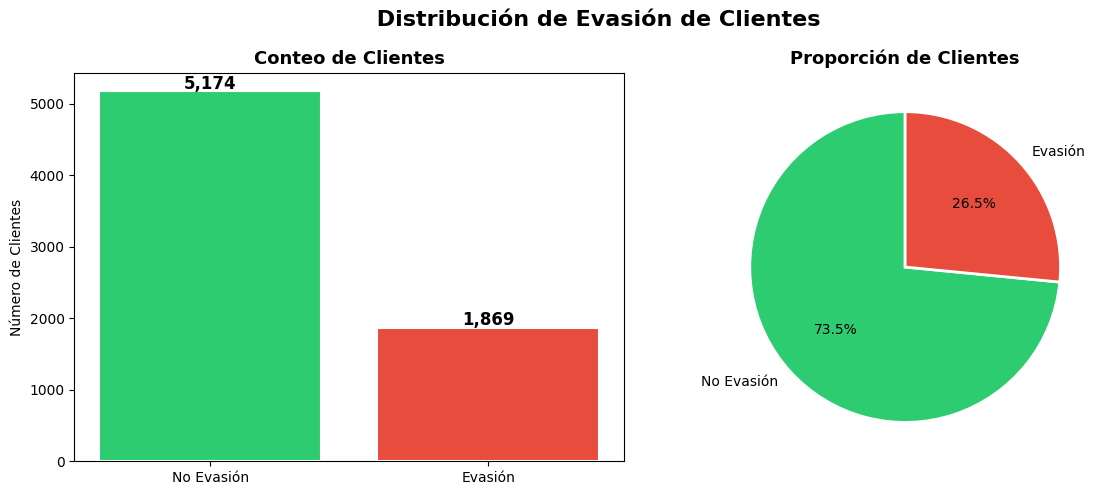


 RESUMEN:
  Clientes que permanecieron : 5,174 (73.46%)
  Clientes que se dieron de baja: 1,869 (26.54%)


In [21]:
# Distribución de Evasión


# Conteo y porcentaje
COLORES = ['#2ecc71', '#e74c3c']
ETIQUETAS = ['No Evasión', 'Evasión']

conteo = df['Evasion'].value_counts()
porcentaje = (df['Evasion'].value_counts(normalize=True) * 100).round(2)

etiquetas = ['No Evasión', 'Evasión']
colores   = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(' Distribución de Evasión de Clientes', fontsize=16, fontweight='bold')

# Gráfico de barras
barras = axes[0].bar(etiquetas, conteo.values, color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Conteo de Clientes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Clientes')
for barra, val in zip(barras, conteo.values):
    axes[0].text(barra.get_x() + barra.get_width()/2,
                 barra.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')

# Gráfico de torta
axes[1].pie(porcentaje.values,
            labels=etiquetas,
            autopct='%1.1f%%',
            colors=colores,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Clientes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Resumen numérico
print("\n RESUMEN:")
print(f"  Clientes que permanecieron : {conteo[0]:,} ({porcentaje[0]}%)")
print(f"  Clientes que se dieron de baja: {conteo[1]:,} ({porcentaje[1]}%)")

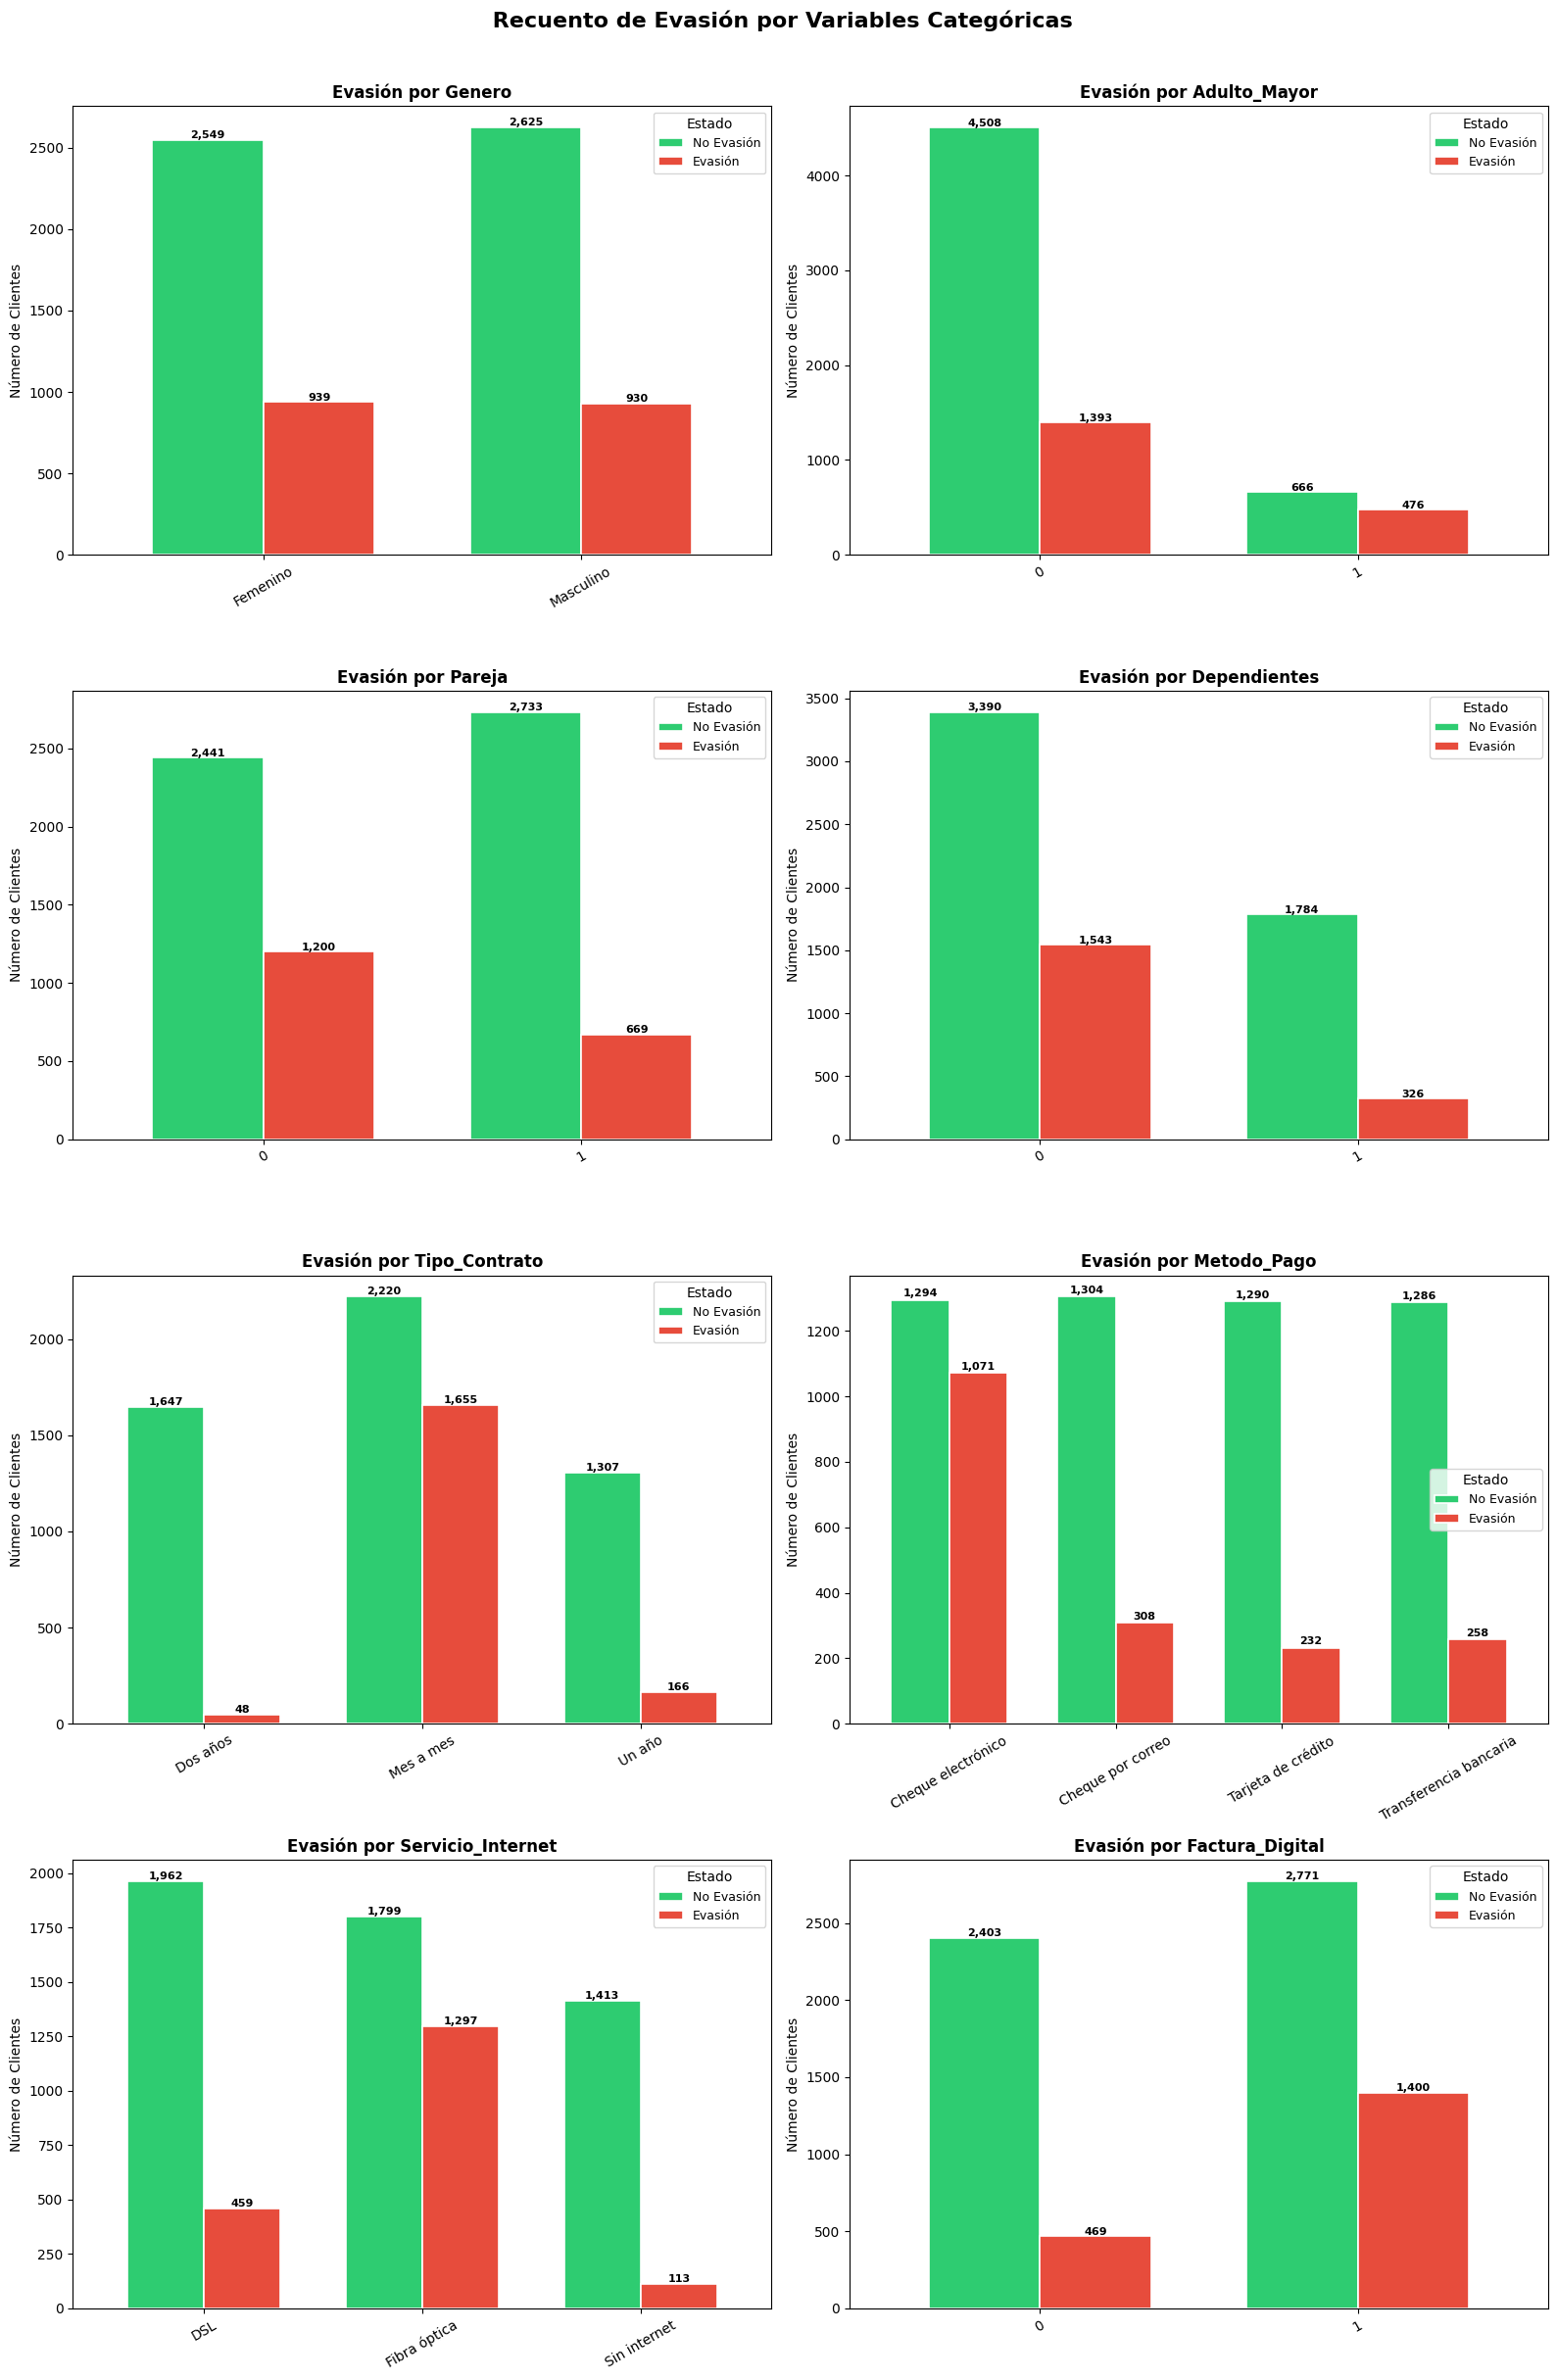


 TASA DE EVASIÓN POR VARIABLE CATEGÓRICA:

   Genero:
     Femenino: 26.92%
     Masculino: 26.16%

   Adulto_Mayor:
     0: 23.61%
     1: 41.68%

   Pareja:
     0: 32.96%
     1: 19.66%

   Dependientes:
     0: 31.28%
     1: 15.45%

   Tipo_Contrato:
     Dos años: 2.83%
     Mes a mes: 42.71%
     Un año: 11.27%

   Metodo_Pago:
     Cheque electrónico: 45.29%
     Cheque por correo: 19.11%
     Tarjeta de crédito: 15.24%
     Transferencia bancaria: 16.71%

   Servicio_Internet:
     DSL: 18.96%
     Fibra óptica: 41.89%
     Sin internet: 7.4%

   Factura_Digital:
     0: 16.33%
     1: 33.57%


In [18]:
# ── Recuento de evasión por variables categóricas
cat_cols = ['Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes',
            'Tipo_Contrato', 'Metodo_Pago', 'Servicio_Internet',
            'Factura_Digital']

fig, axes = plt.subplots(4, 2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Tabla de conteo agrupada
    tabla = df.groupby([col, 'Evasion']).size().unstack(fill_value=0)
    tabla.columns = ['No Evasión', 'Evasión']

    # Gráfico de barras agrupadas
    tabla.plot(kind='bar', ax=axes[i], color=colores,
               edgecolor='white', linewidth=1.2, width=0.7)

    axes[i].set_title(f'Evasión por {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Número de Clientes')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Estado', fontsize=9)

    # Etiquetas encima de cada barra
    for barra in axes[i].patches:
        axes[i].text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 10,
            f'{int(barra.get_height()):,}',
            ha='center', fontsize=8, fontweight='bold'
        )

plt.suptitle(' Recuento de Evasión por Variables Categóricas',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Tasa de evasión por cada variable
print("\n TASA DE EVASIÓN POR VARIABLE CATEGÓRICA:")
print("="*60)
for col in cat_cols:
    print(f"\n   {col}:")
    tasa = df.groupby(col)['Evasion'].mean().mul(100).round(2)
    for categoria, valor in tasa.items():
        print(f"     {categoria}: {valor}%")

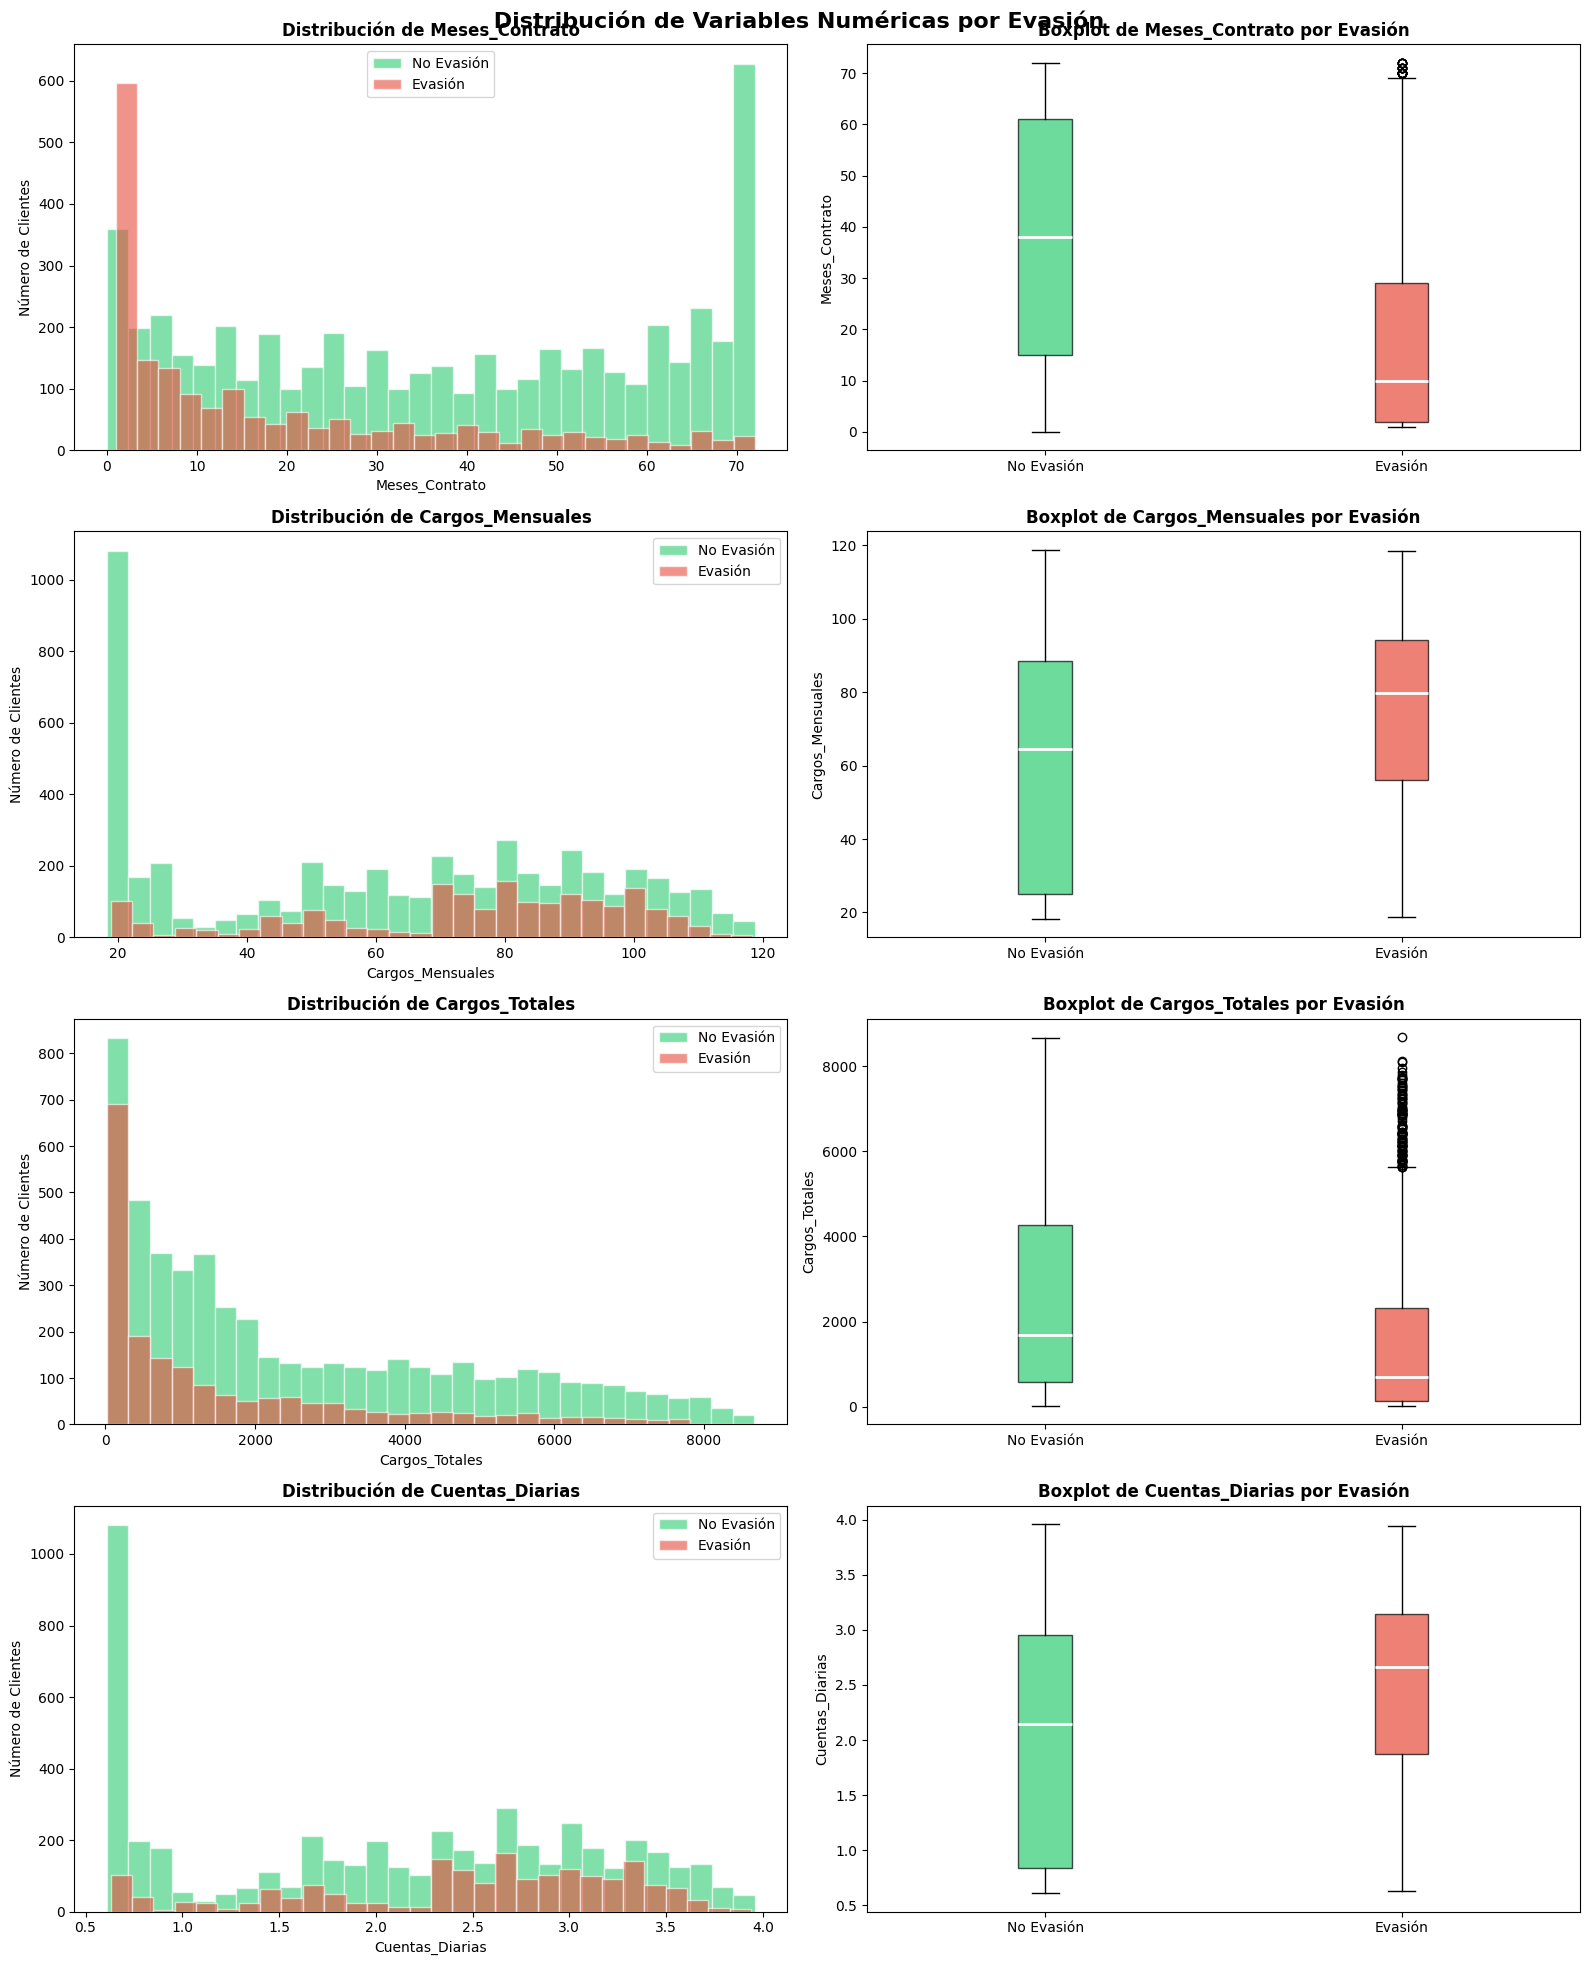


 ESTADÍSTICAS COMPARATIVAS — EVASIÓN vs NO EVASIÓN:

  Meses_Contrato:


,mean,median,std
No Evasión,37.57,38.0,24.11
Evasión,17.98,10.0,19.53



  Cargos_Mensuales:


,mean,median,std
No Evasión,61.27,64.43,31.09
Evasión,74.44,79.65,24.67



  Cargos_Totales:


,mean,median,std
No Evasión,2555.34,1683.60,2329.46
Evasión,1531.80,703.55,1890.82



  Cuentas_Diarias:


,mean,median,std
No Evasión,2.04,2.15,1.04
Evasión,2.48,2.66,0.82


In [23]:
# Conteo de evasión por variables numéricas
num_cols = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
colores = ['#2ecc71', '#e74c3c']
etiquetas = ['No Evasión', 'Evasión']

for i, col in enumerate(num_cols):
    #  Histograma
    for valor, color, etiqueta in zip([0, 1], colores, etiquetas):
        axes[i, 0].hist(
            df[df['Evasion'] == valor][col].dropna(),
            bins=30, alpha=0.6, color=color,
            label=etiqueta, edgecolor='white'
        )
    axes[i, 0].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Número de Clientes')
    axes[i, 0].legend()

    # Boxplot
    data_box = [df[df['Evasion'] == 0][col].dropna(),
                df[df['Evasion'] == 1][col].dropna()]
    bp = axes[i, 1].boxplot(data_box, tick_labels=etiquetas, patch_artist=True,
                             medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i, 1].set_title(f'Boxplot de {col} por Evasión', fontsize=12, fontweight='bold')
    axes[i, 1].set_ylabel(col)

plt.suptitle(' Distribución de Variables Numéricas por Evasión',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas comparativas
print("\n ESTADÍSTICAS COMPARATIVAS — EVASIÓN vs NO EVASIÓN:")
print("="*60)
for col in num_cols:
    print(f"\n  {col}:")
    stats = df.groupby('Evasion')[col].agg(['mean', 'median', 'std']).round(2)
    stats.index = ['No Evasión', 'Evasión']
    display(stats)

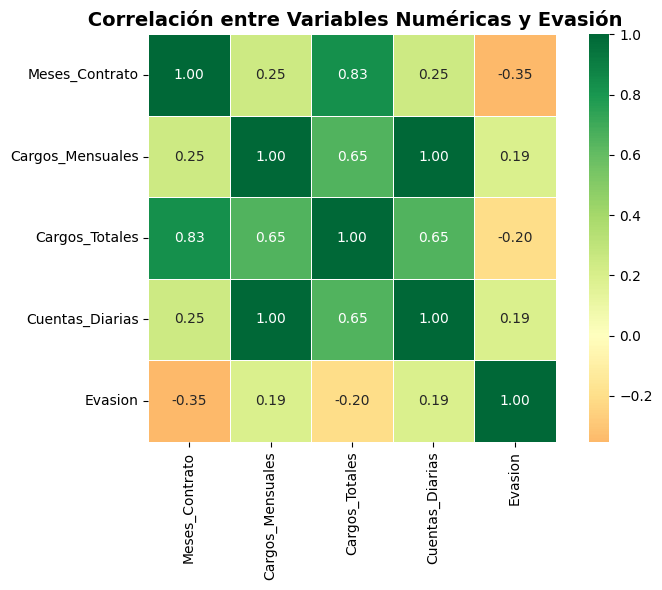


 INTERPRETACIÓN:
  • Valores cercanos a  1.0 → correlación positiva fuerte
  • Valores cercanos a -1.0 → correlación negativa fuerte
  • Valores cercanos a  0.0 → sin correlación lineal


In [24]:
# Heatmap de correlación entre variables numéricas
cols_corr = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias', 'Evasion']

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[cols_corr].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True
)
plt.title(' Correlación entre Variables Numéricas y Evasión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n INTERPRETACIÓN:")
print("  • Valores cercanos a  1.0 → correlación positiva fuerte")
print("  • Valores cercanos a -1.0 → correlación negativa fuerte")
print("  • Valores cercanos a  0.0 → sin correlación lineal")

# Informe Final — TelecomX LATAM
## Análisis de Evasión de Clientes (Churn)

---

## Introducción

La evasión de clientes (o *churn*) es uno de los problemas más costosos para las empresas de telecomunicaciones. Perder un cliente no solo representa la pérdida de ingresos recurrentes, sino que el costo de adquirir uno nuevo es entre **5 y 7 veces mayor** que el de retener uno existente.

TelecomX LATAM enfrenta este desafío de forma directa: aproximadamente **1 de cada 4 clientes** cancela su servicio. Identificar a tiempo quién está en riesgo de irse y por qué es clave para diseñar estrategias de retención efectivas.

**Objetivo del análisis:**
Explorar los datos de 7,267 clientes de TelecomX para identificar los factores demográficos, contractuales y de comportamiento más asociados a la cancelación del servicio, y traducir esos hallazgos en recomendaciones concretas.

**Preguntas que guían el análisis:**
- ¿Qué perfil de cliente tiene mayor probabilidad de cancelar?
- ¿Qué variables —contrato, servicio, facturación— están más asociadas a la evasión?
- ¿Qué acciones puede tomar TelecomX para reducir la tasa de churn?

**Dataset:** 7,267 registros originales con 21 variables sobre características demográficas, servicios contratados y datos de facturación. Tras la limpieza:


## Limpieza y Tratamiento de Datos

El proceso de preparación de datos siguió un pipeline ETL estructurado en tres etapas:

---

### 1. Extracción
- Los datos fueron obtenidos directamente desde una API pública en formato JSON
- Se utilizó `requests.get()` con validación HTTP mediante `response.raise_for_status()` para detectar errores de conexión
- El JSON anidado fue aplanado a un DataFrame tabular usando `pd.json_normalize()`

### 2. Detección y corrección de inconsistencias
Se identificaron dos problemas principales en el dataset original:

| Problema | Columna afectada | Solución aplicada |
|---|---|---|
| Valores vacíos `''` en lugar de nulos | `Churn` | `.replace('', pd.NA)` + `.dropna()` → se eliminaron **224 registros** |
| Tipo de dato incorrecto (`string`) | `account.Charges.Total` | `pd.to_numeric(..., errors='coerce')` → convertida a `float64` |
| Espacios y mayúsculas inconsistentes | Todas las columnas de texto | `.str.strip().str.lower()` |

No se encontraron filas duplicadas en el dataset.

### 3. Transformaciones aplicadas
- **Renombrado:** 21 columnas renombradas al español para mayor legibilidad
- **Variables binarias:** columnas `Evasion`, `Pareja`, `Dependientes`, `Servicio_Telefono` y `Factura_Digital` convertidas de `yes/no` a `1/0`
- **Traducción categórica:** valores de `Genero`, `Tipo_Contrato`, `Metodo_Pago` y `Servicio_Internet` traducidos al español
- **Variable derivada:** se creó `Cuentas_Diarias = Cargos_Mensuales / 30` para analizar el gasto diario por cliente

**Resultado final:** Dataset limpio con **7,043 filas × 22 columnas**, sin nulos en variables clave y con todos los tipos de dato correctos.

## Análisis Exploratorio de Datos

---

### Distribución general de Evasión

El dataset presenta un **desbalance de clases moderado**:

| Estado | Clientes | Porcentaje |
|---|---|---|
| No cancelaron | ~5,174 | 73.5% |
| Cancelaron (churn) | ~1,869 | 26.5% |

Aproximadamente 1 de cada 4 clientes abandona el servicio. Este desbalance es relevante: si se construyera un modelo predictivo en el futuro, sería necesario aplicar técnicas de balanceo (como SMOTE o pesos de clase).

---

### Variables Categóricas

Los gráficos de barras agrupadas revelaron diferencias claras en la tasa de evasión según distintas variables:

| Variable | Categoría con mayor evasión | Tasa aprox. | Categoría con menor evasión | Tasa aprox. |
|---|---|---|---|---|
| Tipo de contrato | Mes a mes | ~43% | Dos años | ~3% |
| Método de pago | Cheque electrónico | ~45% | Transferencia bancaria | ~17% |
| Servicio de internet | Fibra óptica | ~42% | Sin internet | ~7% |
| Factura digital | Sí (digital) | ~33% | No (papel) | ~16% |
| Dependientes | Sin dependientes | ~31% | Con dependientes | ~15% |
| Pareja | Sin pareja | ~33% | Con pareja | ~20% |

El **tipo de contrato** es la variable categórica con mayor diferencia: los clientes mes a mes tienen una tasa de evasión **14 veces mayor** que los de contrato a dos años.

---

### Variables Numéricas

Los histogramas y boxplots mostraron distribuciones claramente diferenciadas entre los grupos:

| Variable | Clientes que permanecen (media) | Clientes que cancelan (media) | Diferencia |
|---|---|---|---|
| Meses de contrato | ~37 meses | ~18 meses | -19 meses |
| Cargos mensuales | ~$61 | ~$74 | +$13 |
| Cargos totales | ~$2,555 | ~$1,532 | -$1,023 |
| Cuentas diarias | ~$2.03 | ~$2.47 | +$0.44 |

Los clientes que cancelan tienen en promedio **menos de la mitad de antigüedad** y pagan **más por mes**, lo que sugiere que son clientes relativamente nuevos que no perciben suficiente valor en el servicio.

---

### Correlaciones entre variables numéricas

El heatmap de correlación reveló tres relaciones clave:

- **`Meses_Contrato` ↔ `Evasion` = -0.35:** correlación negativa moderada — a mayor antigüedad, menor probabilidad de cancelar
- **`Cargos_Mensuales` ↔ `Evasion` = +0.19:** correlación positiva — mayor factura mensual se asocia a mayor riesgo de churn
- **`Cargos_Totales` ↔ `Meses_Contrato` = alta correlación positiva:** estas dos variables son redundantes entre sí (multicolinealidad), lo que debe considerarse en modelos predictivos futuros

## Conclusiones e Insights

El análisis exploratorio permitió identificar con claridad el perfil del cliente con mayor riesgo de evasión y los factores que más influyen en esa decisión.

---

**+ Insight 1 — Los primeros meses son los más críticos**
Los clientes que normalmente cancelan tienen en promedio solo 18 meses de antigüedad, frente a los 37 meses de quienes permanecen. La ventana de mayor riesgo está concentrada en los primeros 12 meses, si TelecomX logra retener a un cliente durante este periodo, la probabilidad de que continúe aumentara significativamente.

**+ Insight 2 — El tipo de contrato es el predictor más poderoso**
La diferencia entre un contrato mes a mes (~43% de churn) y uno a dos años (~3%) es dramática. El contrato mensual quita las barreras de salida y permite al cliente irse en cualquier momento sin alguna consecuencias. Este es el factor con mayor palanca para poder reducir la evasión.

**+ Insight 3 — La Fibra óptica tiene un problema de valor percibido**
Es el servicio más costoso y también el de mayor tasa de evasión (~42%). Esto sugiere que los clientes de fibra no sienten que el precio sea justificado con la calidad o beneficios recibidos. La brecha entre precio y valor percibido está creando una insatisfacción.

**+ Insight 4 — El método de pago refleja el nivel de compromiso**
Los clientes con cheque electrónico "el método más manual" tienen la mayor tasa de evasión (~45%). Los métodos automáticos (débito o tarjeta) están asociados a menor churn, posiblemente porque implican una integración más profunda del cliente con el servicio.

**+ Insight 5 — Los clientes sin red familiar son más vulnerables**
Clientes sin pareja (33% churn) y sin dependientes (31%) cancelan más. Los vínculos familiares actúan como anclas de permanencia cuando hay más personas usando el servicio, la decisión de cancelar es más dificil y mas costosa.

**+ Insight 6 — El perfil de máximo riesgo es identificable**
Un cliente con contrato mes a mes + fibra óptica + cheque electrónico + menos de 12 meses + sin dependientes representa la combinación de factores de mayor riesgo. Este perfil puede usarse para activar alertas tempranas de retención.

Basadas directamente en los hallazgos del análisis, se proponen las siguientes acciones ordenadas por impacto esperado:

---

** 1. Programa de onboarding y fidelización en los primeros 12 meses**
Diseñar un programa de bienvenida activo con la idea de retención a los 3, 6 y 12 meses, descuentos por permanencia, llamadas de seguimiento, beneficios exclusivos por antigüedad. El primer año es la ventana crítica donde se gana o se pierde al cliente.

** 2. Incentivos agresivos para migrar de contratos mensuales a anuales**
Ofrecer descuentos del 15–20% en el primer año de contrato anual, o servicios adicionales gratuitos (streaming, soporte técnico, seguridad online) para los clientes que abandonen el plan mes a mes. El costo del descuento es menor que el costo de reemplazar al cliente.

** 3. Revisión del paquete de Fibra óptica**
Siguimiento de la experiencia del cliente de fibra: velocidad real vs. prometida, tiempos de soporte, problemas recurrentes. Considerar rediseñar el paquete incluyendo servicios adicionales (seguridad y TV en streaming) sin costo extra para mejorar la percepción de valor.

** 4. Incentivo por domiciliación del pago**
Ofrecer un descuento mensual fijo (ej. $5) a clientes que migren del cheque electrónico a débito automático o tarjeta. Reduce la fricción de pago, disminuye la mora y está asociado a mayor retención según los datos.

** 5. Planes familiares y beneficios por dependientes**
Crear ofertas específicas para hogares con múltiples usuarios: descuentos por líneas adicionales, planes compartidos, beneficios de control parental. Los datos muestran que los clientes con familia cancelan menos, lo que incentiva a diseñar productos que construyan ese vínculo.

** 6. Construcción de un modelo predictivo de churn**
Con las variables identificadas en este análisis —especialmente `Meses_Contrato`, `Tipo_Contrato`, `Cargos_Mensuales` y `Metodo_Pago`— el equipo de Data Science puede construir modelos de clasificación (Regresión Logística, Random Forest o XGBoost) para predecir la probabilidad de evasión de cada cliente antes de que ocurra, permitiendo intervenciones proactivas y personalizadas.

---

> **Conclusión general:** TelecomX tiene una tasa de evasión del 26.5% que es controlable. Los datos muestran con claridad que no se trata de un problema random, por ejemplo hay perfiles específicos, servicios concretos y momentos del ciclo de vida donde la evasión se concentra. Poder actuar sobre estos puntos con estrategias directas tienen un potencial de reducir significativamente el churn y mejorar la rentabilidad del negocio.